In [43]:
!pip install understatapi pandas --quiet

In [44]:
import pandas as pd
import understatapi

client = understatapi.UnderstatClient()

league = client.league(league='EPL')
matches = league.get_match_data(season='2025')

df = pd.DataFrame(matches)

In [45]:
shot_data = client.match(match='29142').get_shot_data()
shot_data

{'h': [{'id': '686632',
   'minute': '13',
   'result': 'SavedShot',
   'X': '0.799000015258789',
   'Y': '0.5159999847412109',
   'xG': '0.039518702775239944',
   'player': 'Cole Palmer',
   'h_a': 'h',
   'player_id': '8497',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'LeftFoot',
   'match_id': '29142',
   'h_team': 'Chelsea',
   'a_team': 'Tottenham',
   'h_goals': '2',
   'a_goals': '1',
   'date': '2026-05-19 19:15:00',
   'player_assisted': 'Jorrel Hato',
   'lastAction': 'Pass'},
  {'id': '686633',
   'minute': '17',
   'result': 'Goal',
   'X': '0.7169999694824218',
   'Y': '0.5120000076293946',
   'xG': '0.016422247514128685',
   'player': 'Enzo Fernández',
   'h_a': 'h',
   'player_id': '11356',
   'situation': 'OpenPlay',
   'season': '2025',
   'shotType': 'RightFoot',
   'match_id': '29142',
   'h_team': 'Chelsea',
   'a_team': 'Tottenham',
   'h_goals': '2',
   'a_goals': '1',
   'date': '2026-05-19 19:15:00',
   'player_assisted': 'Pedro Neto',
   'l

In [46]:
type(shot_data)

dict

In [47]:
shot_data.keys()

dict_keys(['h', 'a'])

In [48]:
import pandas as pd

df = pd.DataFrame(shot_data['h'] + shot_data['a'])

df[['X','Y','xG','minute']] = df[['X','Y','xG','minute']].astype(float)

df.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,686632,13.0,SavedShot,0.799,0.516,0.039519,Cole Palmer,h,8497,OpenPlay,2025,LeftFoot,29142,Chelsea,Tottenham,2,1,2026-05-19 19:15:00,Jorrel Hato,Pass
1,686633,17.0,Goal,0.717,0.512,0.016422,Enzo Fernández,h,11356,OpenPlay,2025,RightFoot,29142,Chelsea,Tottenham,2,1,2026-05-19 19:15:00,Pedro Neto,Pass
2,686634,22.0,MissedShots,0.882,0.634,0.077557,Liam Delap,h,8868,OpenPlay,2025,RightFoot,29142,Chelsea,Tottenham,2,1,2026-05-19 19:15:00,Cole Palmer,Pass
3,686635,28.0,ShotOnPost,0.896,0.926,0.033152,Enzo Fernández,h,11356,DirectFreekick,2025,RightFoot,29142,Chelsea,Tottenham,2,1,2026-05-19 19:15:00,None,Standard
4,686637,45.0,MissedShots,0.799,0.485,0.062069,Cole Palmer,h,8497,OpenPlay,2025,RightFoot,29142,Chelsea,Tottenham,2,1,2026-05-19 19:15:00,Enzo Fernández,Pass


In [74]:
df.to_csv("Chelsea vs Tottenham.csv", index=False)

In [75]:
from google.colab import files

files.download("Chelsea vs Tottenham.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
print(df.columns)

Index(['id', 'minute', 'result', 'X', 'Y', 'xG', 'player', 'h_a', 'player_id',
       'situation', 'season', 'shotType', 'match_id', 'h_team', 'a_team',
       'h_goals', 'a_goals', 'date', 'player_assisted', 'lastAction'],
      dtype='object')


In [52]:
print(df[['X','Y']].head())

       X      Y
0  0.799  0.516
1  0.717  0.512
2  0.882  0.634
3  0.896  0.926
4  0.799  0.485


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18 non-null     object 
 1   minute           18 non-null     float64
 2   result           18 non-null     object 
 3   X                18 non-null     float64
 4   Y                18 non-null     float64
 5   xG               18 non-null     float64
 6   player           18 non-null     object 
 7   h_a              18 non-null     object 
 8   player_id        18 non-null     object 
 9   situation        18 non-null     object 
 10  season           18 non-null     object 
 11  shotType         18 non-null     object 
 12  match_id         18 non-null     object 
 13  h_team           18 non-null     object 
 14  a_team           18 non-null     object 
 15  h_goals          18 non-null     object 
 16  a_goals          18 non-null     object 
 17  date             1

# Q1: Which team created higher-quality chances in the match?

In [54]:
# Create a team column
df["team"] = df.apply(
    lambda row: row["h_team"] if row["h_a"] == "h" else row["a_team"],
    axis=1
)

# Total xG per team
team_xg = df.groupby("team")["xG"].sum().sort_values(ascending=False)

print(team_xg)

team
Tottenham    2.238947
Chelsea      1.092620
Name: xG, dtype: float64


# Total xG

In [55]:
df.groupby("team")["xG"].sum()

,xG
team,
Chelsea,1.092620
Tottenham,2.238947


# Number of Shots

In [56]:
df.groupby("team")["id"].count()

,id
team,
Chelsea,9
Tottenham,9


# Average xG per Shot

In [57]:
df.groupby("team")["xG"].mean()

,xG
team,
Chelsea,0.121402
Tottenham,0.248772


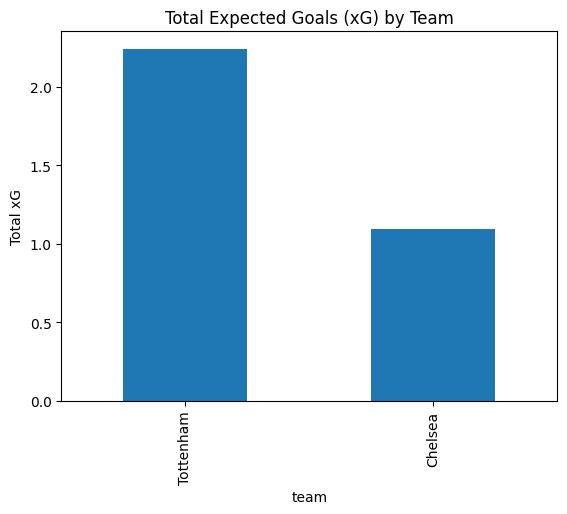

In [58]:
import matplotlib.pyplot as plt

team_xg.plot(kind="bar")
plt.title("Total Expected Goals (xG) by Team")
plt.ylabel("Total xG")
plt.show()

# Q2: Which players were most efficient in chance conversion?

In [59]:
import numpy as np

# Create goal column (1 if goal, 0 otherwise)
df["goal"] = df["result"].apply(lambda x: 1 if x == "Goal" else 0)

# Aggregate by player
player_perf = df.groupby("player").agg(
    shots=("id", "count"),
    xG=("xG", "sum"),
    goals=("goal", "sum")
)

# Efficiency metric
player_perf["xG_diff"] = player_perf["goals"] - player_perf["xG"]
player_perf["conversion_rate"] = player_perf["goals"] / player_perf["shots"]

# Sort by efficiency
player_perf = player_perf.sort_values("xG_diff", ascending=False)

player_perf

,shots,xG,goals,xG_diff,conversion_rate
player,,,,,
Enzo Fernández,2,0.049575,1,0.950425,0.500000
Andrey Santos,1,0.609775,1,0.390225,1.000000
Richarlison,3,1.040199,1,-0.040199,0.333333
Liam Delap,1,0.077557,0,-0.077557,0.000000
Pape Sarr,1,0.121872,0,-0.121872,0.000000
Pedro Neto,2,0.162658,0,-0.162658,0.000000
Cole Palmer,3,0.193054,0,-0.193054,0.000000
Conor Gallagher,1,0.253504,0,-0.253504,0.000000
Mathys Tel,2,0.277401,0,-0.277401,0.000000


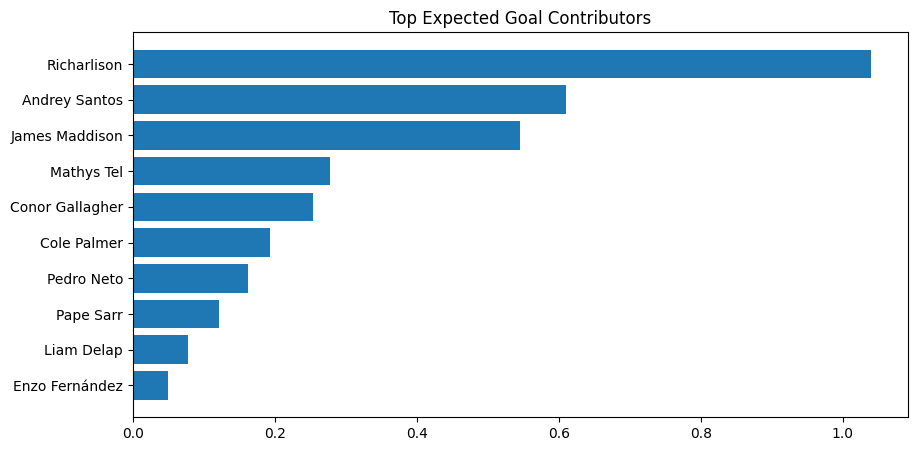

In [60]:
top = player_perf.sort_values("xG", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(range(len(top)), top["xG"])
plt.yticks(range(len(top)), top.index)
plt.title("Top Expected Goal Contributors")
plt.gca().invert_yaxis()
plt.show()

# From which game situations were most dangerous chances created?

# Aggregate xG by Situation

In [61]:
situation_xg = df.groupby("situation").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

situation_xg

,total_xG,shots
situation,,
OpenPlay,2.819378,13
SetPiece,0.272477,1
DirectFreekick,0.183197,3
FromCorner,0.056513,1


In [62]:
situation_xg["xG_per_shot"] = situation_xg["total_xG"] / situation_xg["shots"]
situation_xg

,total_xG,shots,xG_per_shot
situation,,,
OpenPlay,2.819378,13,0.216875
SetPiece,0.272477,1,0.272477
DirectFreekick,0.183197,3,0.061066
FromCorner,0.056513,1,0.056513


In [63]:
team_situation = df.groupby(["team", "situation"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

team_situation.sort_values(["team", "total_xG"], ascending=[True, False])

,team,situation,total_xG,shots
1,Chelsea,OpenPlay,0.968000,7
0,Chelsea,DirectFreekick,0.124619,2
4,Tottenham,OpenPlay,1.851378,6
5,Tottenham,SetPiece,0.272477,1
2,Tottenham,DirectFreekick,0.058578,1
3,Tottenham,FromCorner,0.056513,1


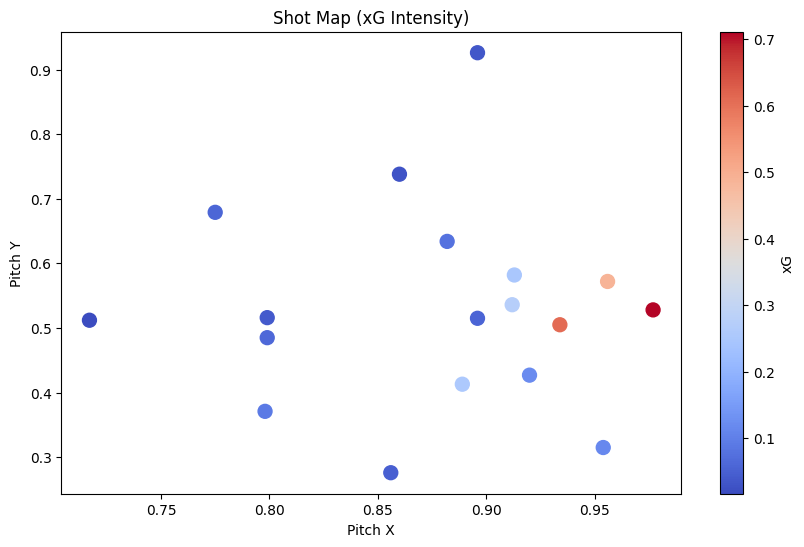

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(df["X"], df["Y"], c=df["xG"], cmap="coolwarm", s=100)

plt.title("Shot Map (xG Intensity)")
plt.xlabel("Pitch X")
plt.ylabel("Pitch Y")
plt.colorbar(label="xG")

plt.show()

In [65]:
player_situation = df.groupby(["team","player", "situation","result"]).agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).reset_index()

player_situation.sort_values("total_xG", ascending=False)

,team,player,situation,result,total_xG,shots
16,Tottenham,Richarlison,OpenPlay,Goal,0.711209,1
0,Chelsea,Andrey Santos,OpenPlay,Goal,0.609775,1
11,Tottenham,James Maddison,OpenPlay,BlockedShot,0.487392,1
17,Tottenham,Richarlison,SetPiece,MissedShots,0.272477,1
9,Tottenham,Conor Gallagher,OpenPlay,SavedShot,0.253504,1
13,Tottenham,Mathys Tel,OpenPlay,ShotOnPost,0.248553,1
14,Tottenham,Pape Sarr,OpenPlay,MissedShots,0.121872,1
8,Chelsea,Pedro Neto,OpenPlay,SavedShot,0.115827,1
1,Chelsea,Cole Palmer,DirectFreekick,BlockedShot,0.091467,1
6,Chelsea,Liam Delap,OpenPlay,MissedShots,0.077557,1


In [66]:
player_situation = df.groupby(["team","result"]).agg(
    shots=("id", "count")
).reset_index()

player_situation.sort_values("shots", ascending=False)

,team,result,shots
7,Tottenham,MissedShots,4
0,Chelsea,BlockedShot,2
1,Chelsea,Goal,2
2,Chelsea,MissedShots,2
8,Tottenham,SavedShot,2
3,Chelsea,SavedShot,2
5,Tottenham,BlockedShot,1
4,Chelsea,ShotOnPost,1
6,Tottenham,Goal,1
9,Tottenham,ShotOnPost,1


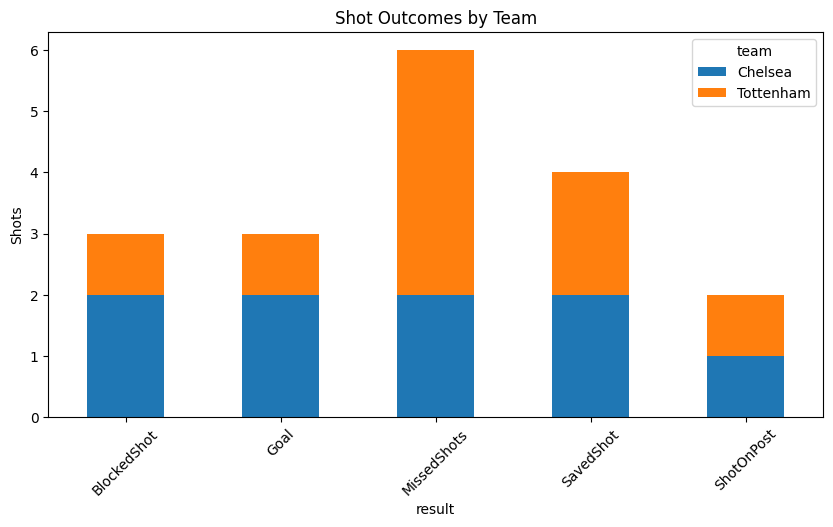

In [67]:
import matplotlib.pyplot as plt

pivot = player_situation.pivot(index="result", columns="team", values="shots").fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Shot Outcomes by Team")
plt.ylabel("Shots")
plt.xticks(rotation=45)
plt.show()

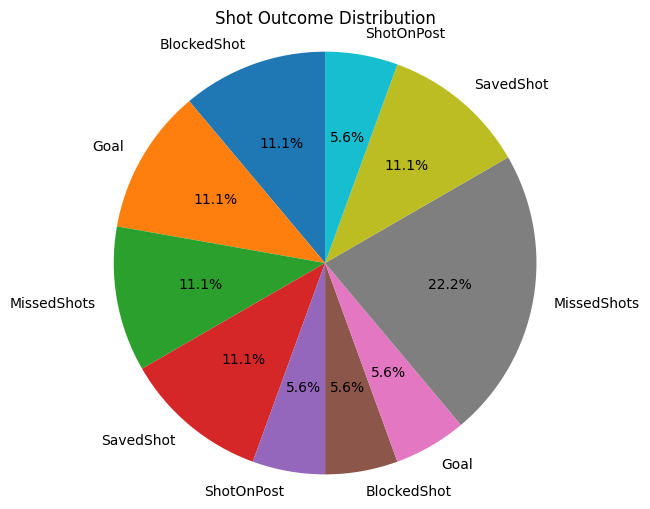

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.pie(
    player_situation["shots"],
    labels=player_situation["result"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Shot Outcome Distribution")
plt.axis("equal")  # keeps it circular
plt.show()

# Q4: What types of shots generated the highest expected value?

In [69]:
shottype_xg = df.groupby("shotType").agg(
    total_xG=("xG", "sum"),
    shots=("id", "count")
).sort_values("total_xG", ascending=False)

shottype_xg

,total_xG,shots
shotType,,
RightFoot,1.479038,10
LeftFoot,1.274984,5
Head,0.577544,3


In [70]:
shottype_xg["xG_per_shot"] = shottype_xg["total_xG"] / shottype_xg["shots"]
shottype_xg

,total_xG,shots,xG_per_shot
shotType,,,
RightFoot,1.479038,10,0.147904
LeftFoot,1.274984,5,0.254997
Head,0.577544,3,0.192515


# Q5: Where on the pitch were the most dangerous shots taken?

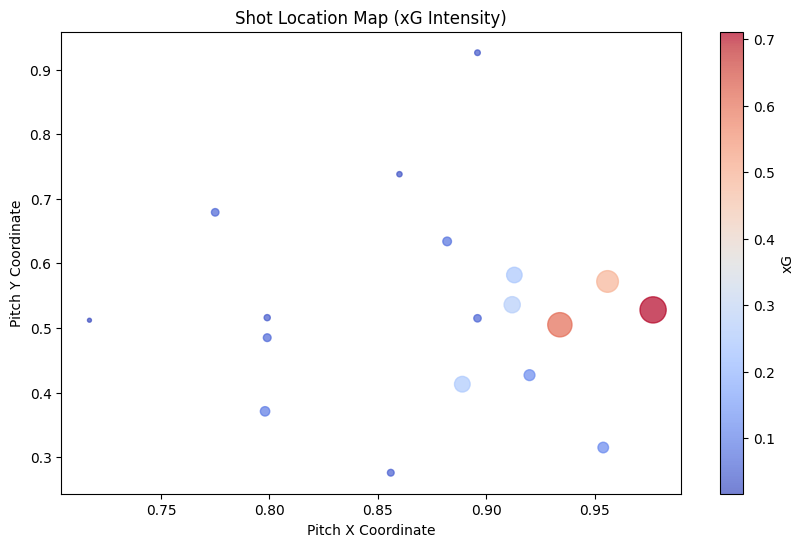

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df["X"],
    df["Y"],
    c=df["xG"],
    s=df["xG"] * 500,
    cmap="coolwarm",
    alpha=0.7
)

plt.title("Shot Location Map (xG Intensity)")
plt.xlabel("Pitch X Coordinate")
plt.ylabel("Pitch Y Coordinate")

plt.colorbar(label="xG")

plt.show()

In [72]:
shots_counts= df.groupby(["team","player", "X","Y","xG"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

         team           player      X      Y        xG       result  shots
0     Chelsea    Andrey Santos  0.934  0.505  0.609775         Goal      1
1     Chelsea      Cole Palmer  0.798  0.371  0.091467  BlockedShot      1
2     Chelsea      Cole Palmer  0.799  0.485  0.062069  MissedShots      1
3     Chelsea      Cole Palmer  0.799  0.516  0.039519    SavedShot      1
4     Chelsea   Enzo Fernández  0.717  0.512  0.016422         Goal      1
5     Chelsea   Enzo Fernández  0.896  0.926  0.033152   ShotOnPost      1
6     Chelsea       Liam Delap  0.882  0.634  0.077557  MissedShots      1
7     Chelsea       Pedro Neto  0.856  0.276  0.046831  BlockedShot      1
8     Chelsea       Pedro Neto  0.954  0.315  0.115827    SavedShot      1
9   Tottenham  Conor Gallagher  0.889  0.413  0.253504    SavedShot      1
10  Tottenham   James Maddison  0.775  0.679  0.058578  MissedShots      1
11  Tottenham   James Maddison  0.956  0.572  0.487392  BlockedShot      1
12  Tottenham       Mathy

In [73]:
shots_counts= df.groupby(["team","player", "X","Y","xG","situation"])["result"].value_counts().reset_index(name="shots")
print(shots_counts)

         team           player      X      Y        xG       situation  \
0     Chelsea    Andrey Santos  0.934  0.505  0.609775        OpenPlay   
1     Chelsea      Cole Palmer  0.798  0.371  0.091467  DirectFreekick   
2     Chelsea      Cole Palmer  0.799  0.485  0.062069        OpenPlay   
3     Chelsea      Cole Palmer  0.799  0.516  0.039519        OpenPlay   
4     Chelsea   Enzo Fernández  0.717  0.512  0.016422        OpenPlay   
5     Chelsea   Enzo Fernández  0.896  0.926  0.033152  DirectFreekick   
6     Chelsea       Liam Delap  0.882  0.634  0.077557        OpenPlay   
7     Chelsea       Pedro Neto  0.856  0.276  0.046831        OpenPlay   
8     Chelsea       Pedro Neto  0.954  0.315  0.115827        OpenPlay   
9   Tottenham  Conor Gallagher  0.889  0.413  0.253504        OpenPlay   
10  Tottenham   James Maddison  0.775  0.679  0.058578  DirectFreekick   
11  Tottenham   James Maddison  0.956  0.572  0.487392        OpenPlay   
12  Tottenham       Mathys Tel  0.860 

In [32]:
pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.9 MB/s eta 0:00:00


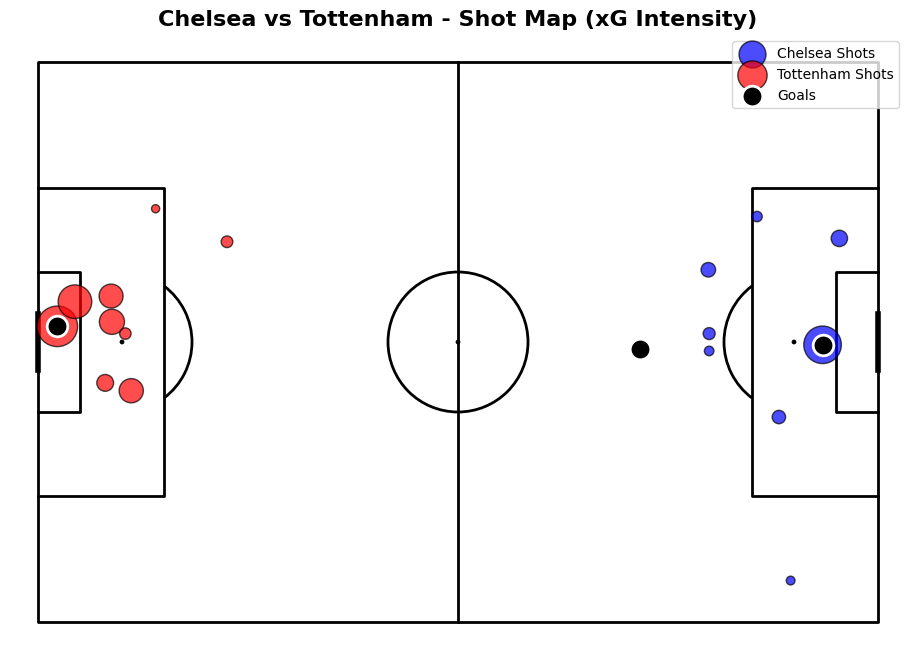

In [77]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# TEAM NAMES (based on your dataset)
# -----------------------------
home_team = "Chelsea"
away_team = "Tottenham"

# -----------------------------
# ADD HOME/AWAY LABEL
# -----------------------------
df['h_team'] = home_team
df['a_team'] = away_team

df['h_a'] = df['team'].apply(lambda x: 'h' if x == home_team else 'a')

# -----------------------------
# CONVERT UNDERSTAT COORDINATES
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# IMPORTANT (keeps attacking direction consistent)
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black'
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME SHOTS (Chelsea)
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 1200,
    color='blue',
    edgecolors='black',
    alpha=0.7,
    label=f'{home_team} Shots'
)

# -----------------------------
# AWAY SHOTS (Tottenham)
# -----------------------------
ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 1200,
    color='red',
    edgecolors='black',
    alpha=0.7,
    label=f'{away_team} Shots'
)

# -----------------------------
# GOALS ONLY
# -----------------------------
goals = df[df['result'] == 'Goal'].copy()

home_goals = goals[goals['h_a'] == 'h'].copy()
away_goals = goals[goals['h_a'] == 'a'].copy()

# flip away goals
away_goals['x'] = 120 - (away_goals['X'] * 120)
away_goals['y'] = 80 - (away_goals['Y'] * 80)

# home goals
home_goals['x'] = home_goals['X'] * 120
home_goals['y'] = home_goals['Y'] * 80

goal_plot = pd.concat([home_goals, away_goals])

ax.scatter(
    goal_plot['x'],
    goal_plot['y'],
    s=220,
    color='black',
    edgecolors='white',
    linewidth=2,
    zorder=5,
    label='Goals'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} - Shot Map (xG Intensity)',
    fontsize=16,
    fontweight='bold'
)

plt.legend(loc='upper right')
plt.show()

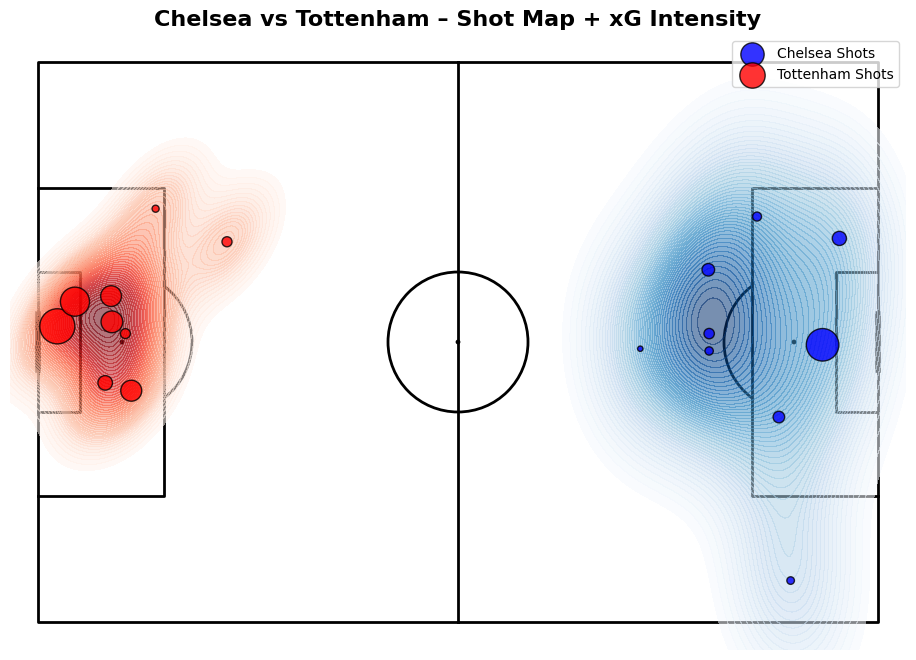

In [76]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -----------------------------
# COPY DATA
# -----------------------------
df = df.copy()

# -----------------------------
# ADD TEAM LABELS (since your dataset doesn't have h/a)
# -----------------------------
home_team = "Chelsea"
away_team = "Tottenham"

df['h_team'] = home_team
df['a_team'] = away_team

# assign home/away manually
df['h_a'] = df['team'].apply(lambda x: 'h' if x == home_team else 'a')

# -----------------------------
# CONVERT COORDINATES (Understat → StatsBomb scale)
# -----------------------------
df['x'] = df['X'] * 120
df['y'] = df['Y'] * 80

# -----------------------------
# SPLIT TEAMS
# -----------------------------
home = df[df['h_a'] == 'h'].copy()
away = df[df['h_a'] == 'a'].copy()

# -----------------------------
# FLIP AWAY TEAM
# -----------------------------
away['x'] = 120 - away['x']
away['y'] = 80 - away['y']

# -----------------------------
# CREATE PITCH
# -----------------------------
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='white',
    line_color='black',
    linewidth=2
)

fig, ax = plt.subplots(figsize=(12, 8))
pitch.draw(ax=ax)

# -----------------------------
# HOME TEAM HEATMAP (Chelsea)
# -----------------------------
sns.kdeplot(
    x=home['x'],
    y=home['y'],
    fill=True,
    cmap='Blues',
    alpha=0.55,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# AWAY TEAM HEATMAP (Tottenham)
# -----------------------------
sns.kdeplot(
    x=away['x'],
    y=away['y'],
    fill=True,
    cmap='Reds',
    alpha=0.55,
    levels=50,
    thresh=0.05,
    ax=ax
)

# -----------------------------
# SHOT SIZE = xG
# -----------------------------
ax.scatter(
    home['x'],
    home['y'],
    s=home['xG'] * 900,
    color='blue',
    edgecolors='black',
    alpha=0.8,
    label='Chelsea Shots'
)

ax.scatter(
    away['x'],
    away['y'],
    s=away['xG'] * 900,
    color='red',
    edgecolors='black',
    alpha=0.8,
    label='Tottenham Shots'
)

# -----------------------------
# TITLE
# -----------------------------
plt.title(
    f'{home_team} vs {away_team} – Shot Map + xG Intensity',
    fontsize=16,
    fontweight='bold'
)

plt.legend(loc='upper right')
plt.show()